In [1]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg')
%matplotlib inline
import random as random
import numpy as np
import csv

In [2]:
x_data = [ 338.,  333.,  328. , 207. , 226.  , 25. , 179. ,  60. , 208.,  606.]
y_data = [  640.  , 633. ,  619.  , 393.  , 428. ,   27.  , 193.  ,  66. ,  226. , 1591.]

In [3]:
x_data @ y_data

TypeError: unsupported operand type(s) for @: 'list' and 'list'

In [4]:
x = np.arange(-200,-100,1) #bias
y = np.arange(-5,5,0.1) #weight
Z =  np.zeros((len(x), len(y)))
X, Y = np.meshgrid(x, y)
for i in range(len(x)):
	for j in range(len(y)):
		b = x[i]
		w = y[j]
		Z[j][i] = 0
		for n in range(len(x_data)):
			Z[j][i] = Z[j][i] +  (y_data[n] - b - w*x_data[n])**2
		Z[j][i] = Z[j][i]/len(x_data)

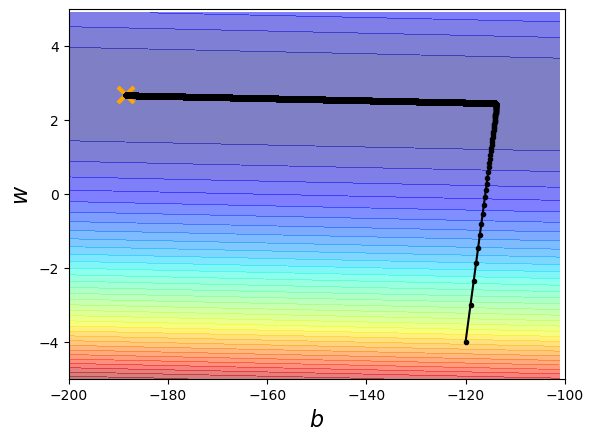

In [6]:
# ydata = b + w * xdata 
b = -120 # initial b
w = -4 # initial w
lr = 1 # learning rate
iteration = 100000



b_lr = 0.0
w_lr = 0.0

# Store initial values for plotting.
b_history = [b]
w_history = [w]

# Iterations
for i in range(iteration):
    
    b_grad = 0.0
    w_grad = 0.0
    for n in range(len(x_data)):        
        b_grad = b_grad  - 2.0*(y_data[n] - b - w*x_data[n])*1.0
        w_grad = w_grad  - 2.0*(y_data[n] - b - w*x_data[n])*x_data[n]
    
    b_lr = b_lr + b_grad**2
    w_lr = w_lr + w_grad**2
    
    # Update parameters.
    b = b - lr/np.sqrt(b_lr) * b_grad 
    w = w - lr/np.sqrt(w_lr) * w_grad
    
    # Store parameters for plotting
    b_history.append(b)
    w_history.append(w)

# plot the figure
plt.contourf(x,y,Z, 50, alpha=0.5, cmap=plt.get_cmap('jet'))
plt.plot([-188.4], [2.67], 'x', ms=12, markeredgewidth=3, color='orange')
plt.plot(b_history, w_history, 'o-', ms=3, lw=1.5, color='black')
plt.xlim(-200,-100)
plt.ylim(-5,5)
plt.xlabel(r'$b$', fontsize=16)
plt.ylabel(r'$w$', fontsize=16)
plt.show()

理论最优解计算方法：![alt text](image.png)

$$E = mc^2$$

$$\int_{-\infty}^{\infty} e^{-x^2} dx = \sqrt{\pi}$$

$$f_n = y_n -b - wx_n $$

$$L = \frac{1}{N}\sum_{i=1}^{n}f_n^2 $$

$$\frac{\partial L}{\partial w}= \frac{1}{N}\sum_{i=1}^{n} 2 f_n * \frac{\partial f_n}{\partial w} $$ 


$$f_n = y_n - wx_n -b$$
$$L = \frac{1}{N}\sum_{n=1}^{N}(y_n-b-wx_n)^2$$

$$\frac{\partial f_n}{\partial w} = -x_n$$

$$\frac{\partial L}{\partial w} = \frac{1}{N}\sum_{i=1}^n 2 (y_n -b - wx_n) (-x_n)$$

$$\frac{\partial L}{\partial w} = \frac{1}{N}\sum_{i=1}^n-2(y_n-b-wx_n)x_n$$